# Phase 2: EDA

In [ ]:
#Libraries for exploratory analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rdkit


#Load data

df = pd.read_csv("c:/Users/felip/drug-likeness-project/data/B3DB_classification.tsv", sep = "\t")

print("Shape: ", df.shape)
print("\ncolumns: ", df.columns.tolist())
print("\nDataatypes: ", df.dtypes)



Shape:  (7807, 12)

columns:  ['NO.', 'compound_name', 'IUPAC_name', 'SMILES', 'CID', 'logBB', 'BBB+/BBB-', 'Inchi', 'threshold', 'reference', 'group', 'comments']

Dataatypes:  NO.                int64
compound_name     object
IUPAC_name        object
SMILES            object
CID              float64
logBB            float64
BBB+/BBB-         object
Inchi             object
threshold        float64
reference         object
group             object
comments          object
dtype: object


In [3]:
#Check for nulls

print("Missing values per column: ")
print(df.isnull().sum())

Missing values per column: 
NO.                 0
compound_name    1109
IUPAC_name       1637
SMILES              0
CID              1637
logBB            6749
BBB+/BBB-           0
Inchi               0
threshold        4186
reference           0
group               0
comments         7789
dtype: int64


['BBB+/BBB-'] Series([], Name: count, dtype: int64)


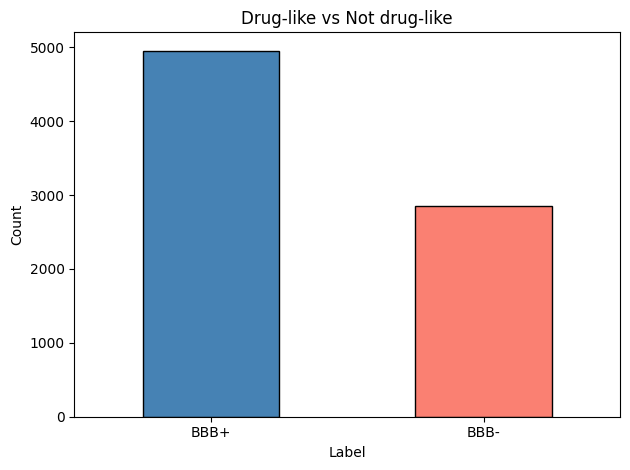

In [4]:
#Class imbalance 

print(["BBB+/BBB-"], df.value_counts())

df["BBB+/BBB-"].value_counts().plot(
    kind = "bar",
    color = ["steelblue", "salmon"],
    edgecolor = "black"
)

plt.title("Drug-like vs Not drug-like")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
#Data we will actually need

df = df[["compound_name", "BBB+/BBB-", "SMILES"]]
print(df.shape)
print(df.isnull().sum())

(7807, 3)
compound_name    1109
BBB+/BBB-           0
SMILES              0
dtype: int64


In [8]:
#Creating Lipinski values from the SMILES column

from rdkit import Chem
from rdkit.Chem import Descriptors

def get_lipinski(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None, None, None
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = Descriptors.NumHDonors(mol)
    hba  = Descriptors.NumHAcceptors(mol)
    return mw, logp, hbd, hba

df[["MW", "LogP", "HBD", "HBA"]] = df["SMILES"].apply(
    lambda s: pd.Series(get_lipinski(s))
)

print(df.head())
print(df.isnull().sum())

                         compound_name BBB+/BBB-  \
0                       sulphasalazine      BBB-   
1                           moxalactam      BBB-   
2                           clioquinol      BBB-   
3  bbcpd11 (cimetidine analog) (y-g13)      BBB-   
4                        schembl614298      BBB-   

                                              SMILES       MW     LogP  HBD  \
0   O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O  398.400  3.70160  3.0   
1  COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...  520.480 -1.12770  4.0   
2                             Oc1c(I)cc(Cl)c2cccnc12  305.502  3.19840  1.0   
3                         CCNC(=NCCSCc1ncccc1Br)NC#N  342.266  2.11348  2.0   
4  CN1CC[C@]23c4c5ccc(OC6O[C@H](C(=O)O)[C@@H](O)[...  461.467 -1.23650  5.0   

    HBA  
0   7.0  
1  12.0  
2   2.0  
3   4.0  
4   9.0  
compound_name    1109
BBB+/BBB-           0
SMILES              0
MW                  0
LogP                0
HBD                 0
HBA                 

In [10]:
#Resetting dataframe to columns that will be used in training

df = df.dropna(subset=["MW", "LogP", "HBD", "HBA", "BBB+/BBB-"])
df = df.reset_index(drop=True)
print("Clean shape:", df.shape)

#Statistics

df.describe()

Clean shape: (7807, 7)


,MW,LogP,HBD,HBA
count,7807.000000,7807.000000,7807.000000,7807.000000
mean,385.447384,2.356028,2.009991,5.418343
std,170.867047,2.195464,2.262473,3.696355
min,6.941000,-8.895300,0.000000,0.000000
25%,285.343000,1.202650,1.000000,3.000000
50%,362.466000,2.547800,1.000000,4.000000
75%,451.582500,3.786400,3.000000,7.000000
max,1882.332000,12.605800,24.000000,33.000000


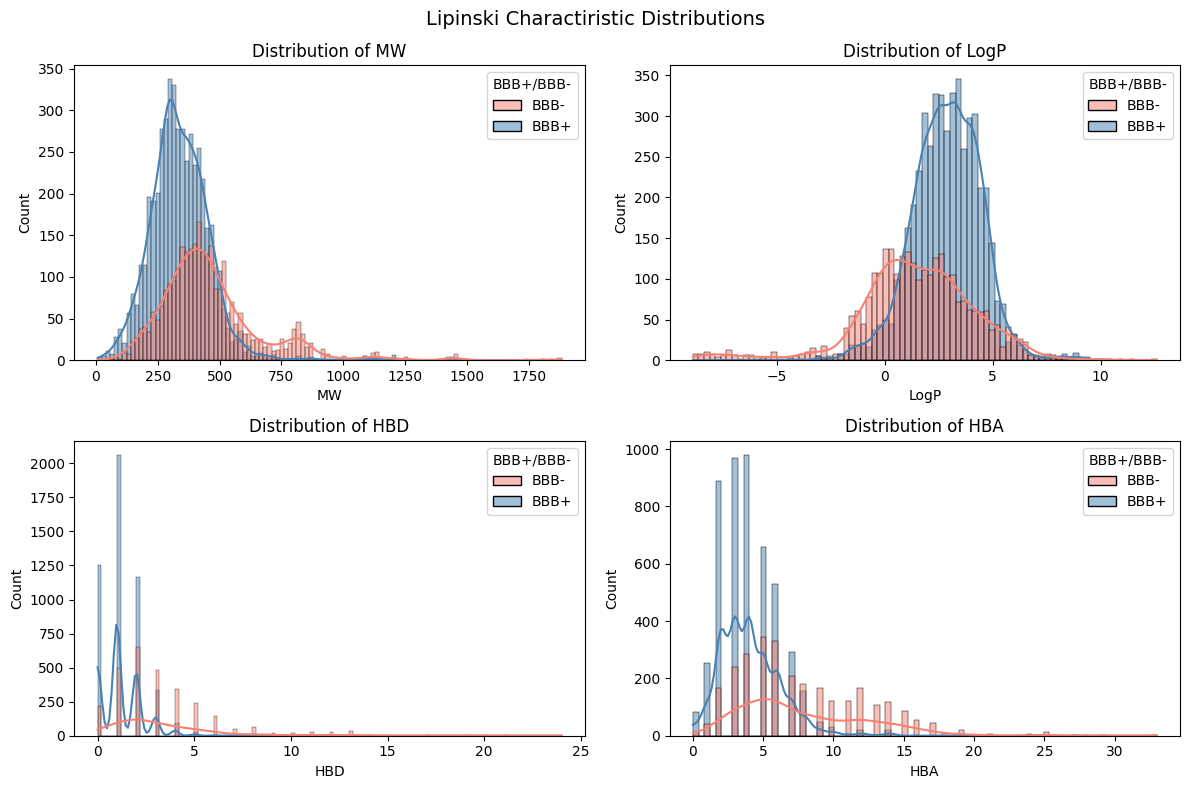

In [15]:
#Distribution of charactiristics

charactiristics = ["MW", "LogP", "HBD", "HBA"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(charactiristics):
    sns.histplot(
        data = df,
        x = col,
        hue = "BBB+/BBB-",
        kde = True,
        ax = axes[i],
        palette = ["salmon", "steelblue"]
    )
    axes[i].set_title(f"Distribution of {col}")

plt.suptitle("Lipinski Charactiristic Distributions", fontsize=14)
plt.tight_layout()
plt.show()

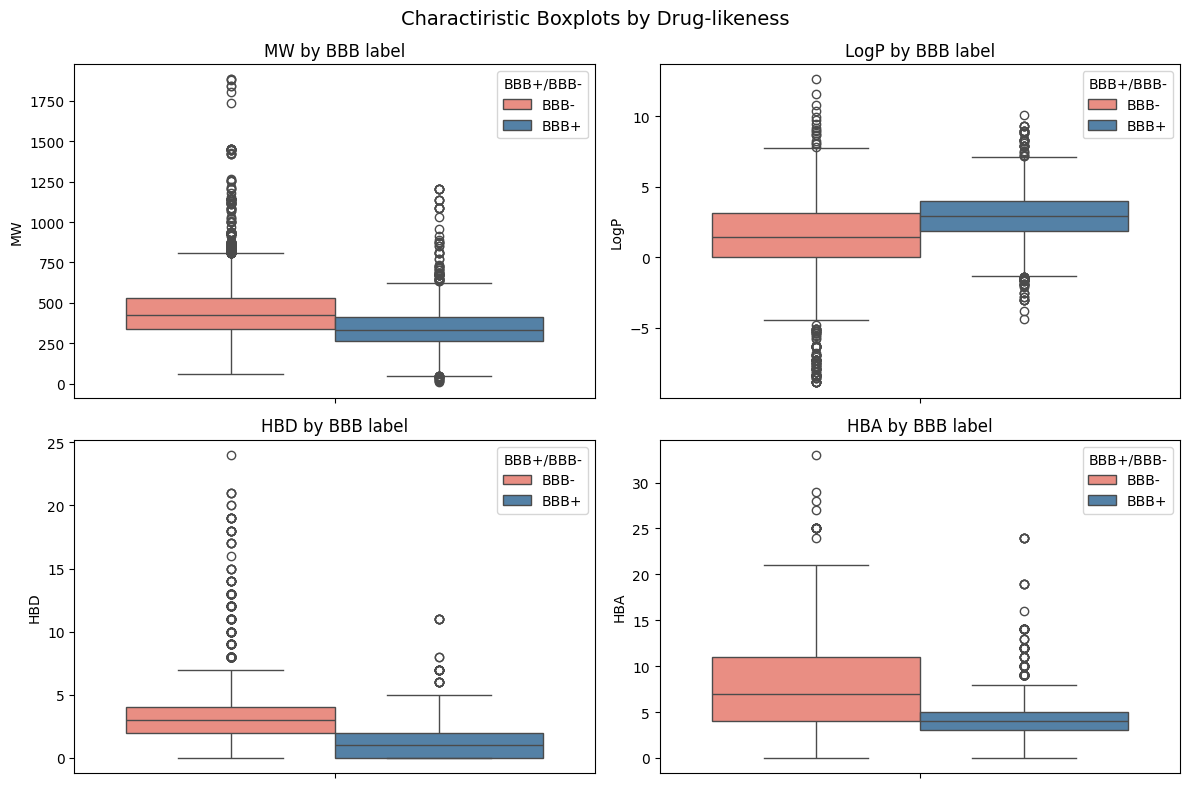

In [17]:
charactiristics = ["MW", "LogP", "HBD", "HBA"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(charactiristics):
    sns.boxplot(
        data = df,
        hue = "BBB+/BBB-",
        legend = True,
        y = col,
        palette = ["salmon", "steelblue"],
        ax = axes[i]
    )
    axes[i].set_title(f"{col} by BBB label")

plt.suptitle("Charactiristic Boxplots by Drug-likeness", fontsize=14)
plt.tight_layout()
plt.show()

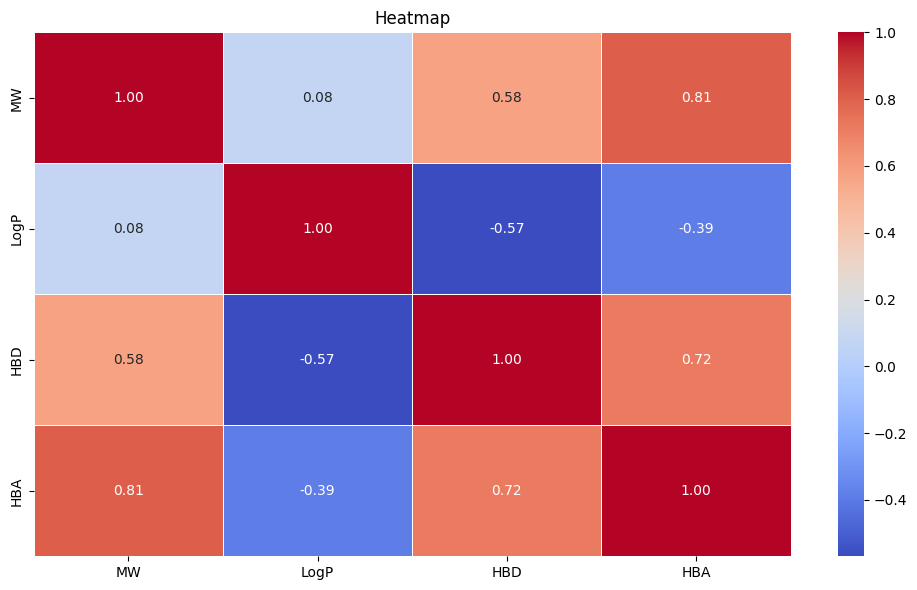

In [18]:
#Correlation of each charactiristic to the class

numeric_df = df.select_dtypes(include="number")
numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    numeric_df.corr(),
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm",
    linewidths = 0.5
)
plt.title("Heatmap")
plt.tight_layout()
plt.show()

In [21]:
#Saving new data into dataframe 

df = df.drop(columns=["SMILES"])
df.to_csv("c:/Users/felip/drug-likeness-project/data/B3DB_clean.csv", index=False)
print("Final shape:", df.shape)
print("Columns saved:", df.columns.tolist())

Final shape: (7807, 6)
Columns saved: ['compound_name', 'BBB+/BBB-', 'MW', 'LogP', 'HBD', 'HBA']
